athletes shape: (271116, 15)
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   NaN  
1      Judo Men's Extra-Lightweight   NaN

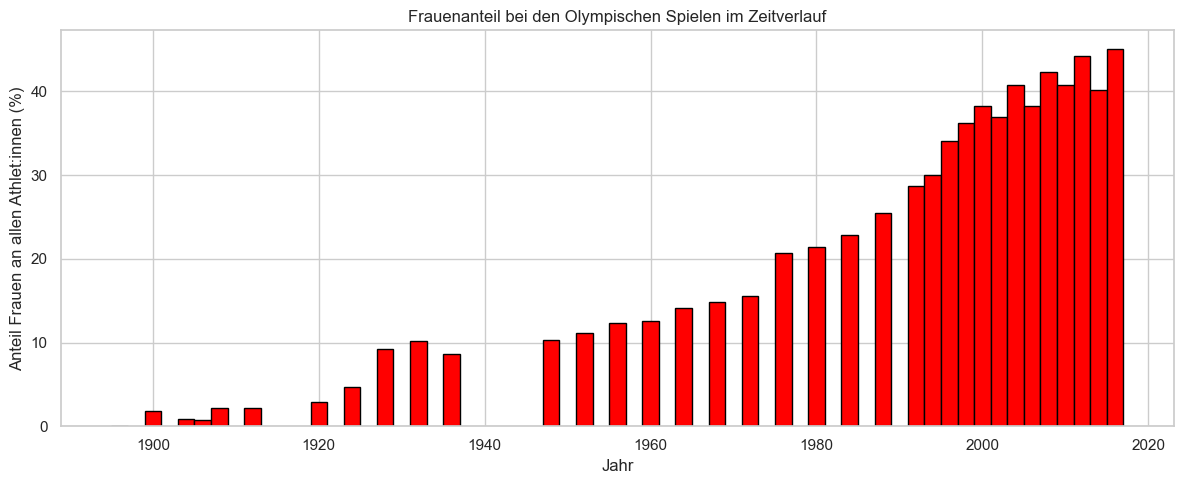

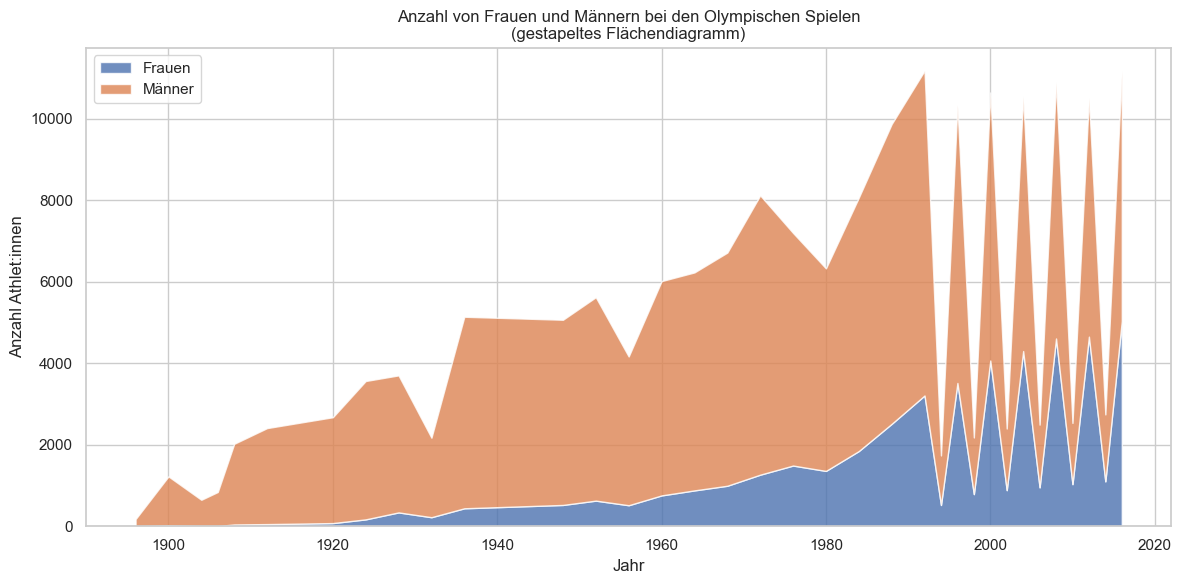

Sex                        F      M   Total  Female_share
Sport                                                    
Softball               367.0    0.0   367.0      1.000000
Rhythmic Gymnastics    567.0    0.0   567.0      1.000000
Synchronized Swimming  550.0    0.0   550.0      1.000000
Gymnastics             768.0  649.0  1417.0      0.541990
Figure Skating         464.0  442.0   906.0      0.512141


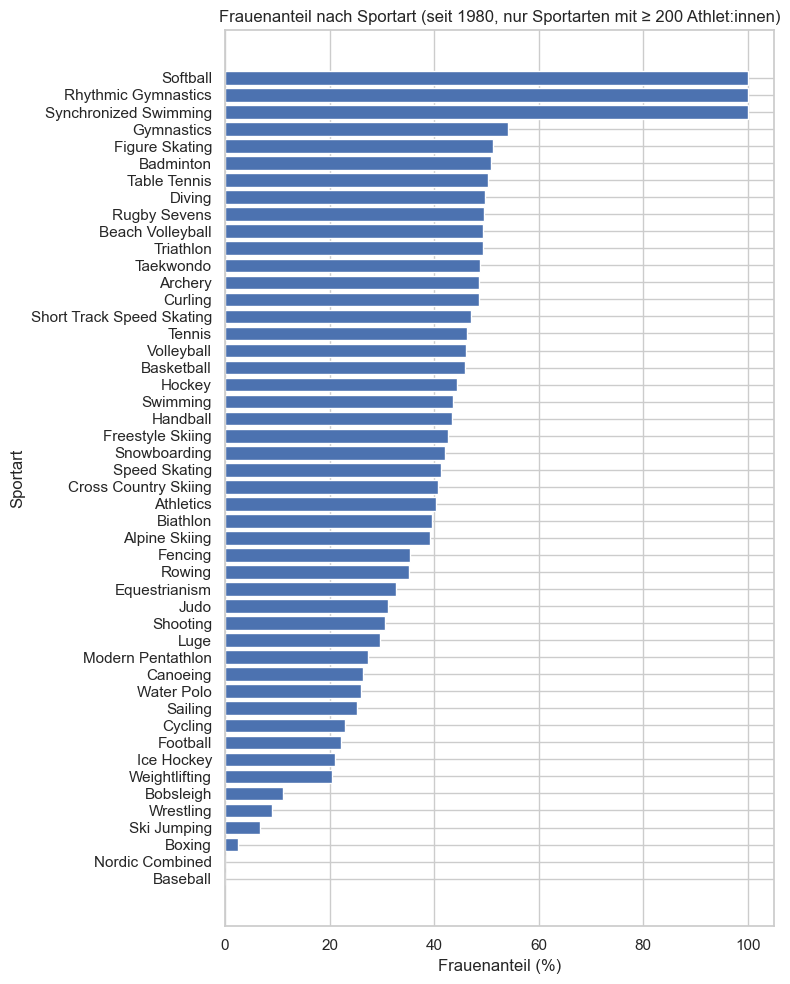

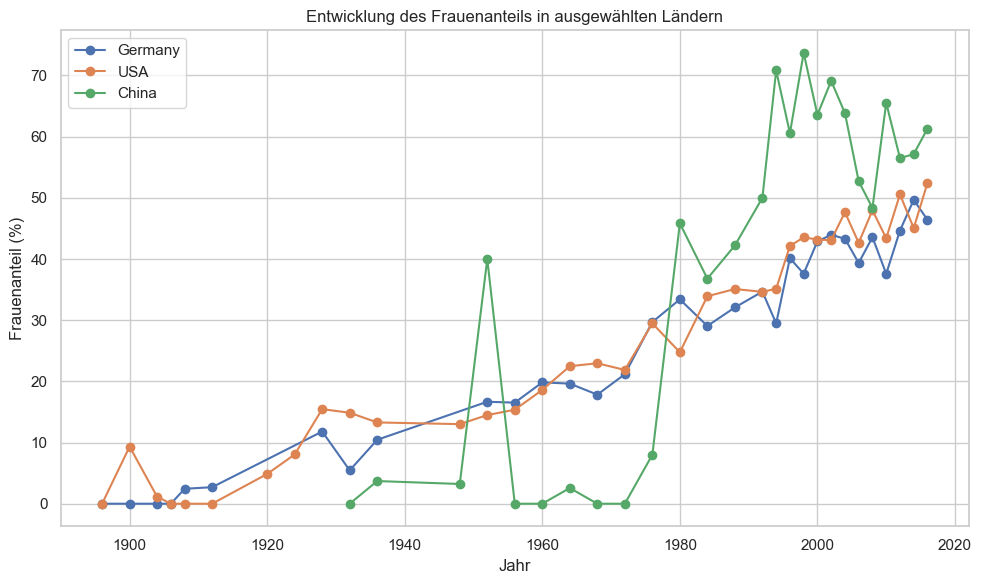

   Year       Sport Sex  Participants  Medalists  Medal_rate
0  1980   Athletics   F           266         53    0.199248
1  1980   Athletics   M           694         82    0.118156
2  1980  Gymnastics   F            62         18    0.290323
3  1980  Gymnastics   M            65         20    0.307692
4  1980    Swimming   F           143         44    0.307692


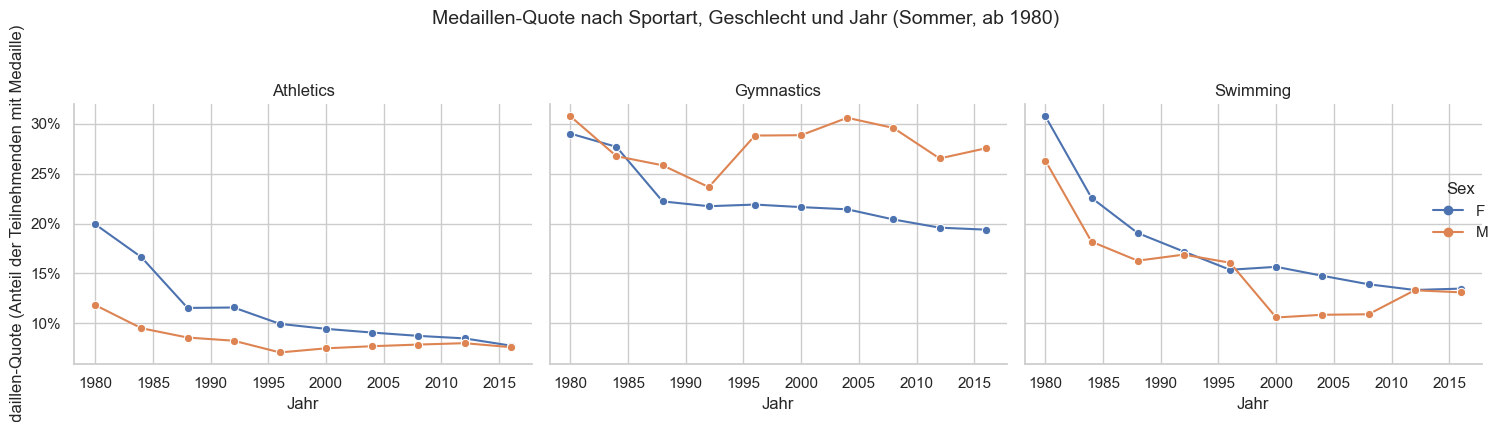

In [6]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

athletes = pd.read_csv("athlete_events.csv")
noc = pd.read_csv("noc_regions.csv")

print("athletes shape:", athletes.shape)
print(athletes.head())

athletes = athletes[athletes["Sex"].isin(["F", "M"])]

athletes = athletes.dropna(subset=["Year"])
athletes["Year"] = athletes["Year"].astype(int)

participants_per_year_sex = (
    athletes.groupby(["Year", "Sex"])["ID"]
    .nunique()     
    .unstack("Sex")   
    .fillna(0)
    .sort_index()
)

participants_per_year_sex["Total"] = (
    participants_per_year_sex["F"] + participants_per_year_sex["M"]
)
participants_per_year_sex["Female_share"] = (
    participants_per_year_sex["F"] / participants_per_year_sex["Total"]
)

print(participants_per_year_sex.head())

plt.figure(figsize=(12, 5))
plt.bar(
    participants_per_year_sex.index,               
    participants_per_year_sex["Female_share"] * 100, 
    width=2.0,
    edgecolor="black",
    color="red" 
)
plt.xlabel("Jahr")
plt.ylabel("Anteil Frauen an allen Athlet:innen (%)")
plt.title("Frauenanteil bei den Olympischen Spielen im Zeitverlauf")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

years = participants_per_year_sex.index
women = participants_per_year_sex["F"]
men   = participants_per_year_sex["M"]

plt.stackplot(
    years,
    women,
    men,
    labels=["Frauen", "Männer"],
    alpha=0.8
)

plt.xlabel("Jahr")
plt.ylabel("Anzahl Athlet:innen")
plt.title("Anzahl von Frauen und Männern bei den Olympischen Spielen\n(gestapeltes Flächendiagramm)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


recent = athletes[athletes["Year"] >= 1980]

sport_gender_counts = (
    recent.groupby(["Sport", "Sex"])["ID"]
    .nunique()
    .unstack("Sex")
    .fillna(0)
)

sport_gender_counts["Total"] = sport_gender_counts["F"] + sport_gender_counts["M"]
sport_gender_counts["Female_share"] = sport_gender_counts["F"] / sport_gender_counts["Total"]

sport_gender_counts = sport_gender_counts[sport_gender_counts["Total"] >= 200]

sport_gender_counts = sport_gender_counts.sort_values("Female_share", ascending=False)

print(sport_gender_counts.head())

plt.figure(figsize=(8, 10))
plt.barh(
    sport_gender_counts.index,
    sport_gender_counts["Female_share"] * 100
)
plt.xlabel("Frauenanteil (%)")
plt.ylabel("Sportart")
plt.title("Frauenanteil nach Sportart (seit 1980, nur Sportarten mit ≥ 200 Athlet:innen)")
plt.gca().invert_yaxis()   
plt.tight_layout()
plt.show()

athletes_region = athletes.merge(noc[["NOC", "region"]], on="NOC", how="left")

countries = ["Germany", "USA", "China"]

country_data = (
    athletes_region[athletes_region["region"].isin(countries)]
    .groupby(["Year", "region", "Sex"])["ID"]
    .nunique()
    .unstack("Sex")
    .fillna(0)
)

country_data["Total"] = country_data["F"] + country_data["M"]
country_data["Female_share"] = country_data["F"] / country_data["Total"]
country_data = country_data.reset_index()

plt.figure(figsize=(10, 6))
for country in countries:
    subset = country_data[country_data["region"] == country]
    plt.plot(
        subset["Year"],
        subset["Female_share"] * 100,
        marker="o",
        label=country
    )

plt.xlabel("Jahr")
plt.ylabel("Frauenanteil (%)")
plt.title("Entwicklung des Frauenanteils in ausgewählten Ländern")
plt.legend()
plt.tight_layout()
plt.show()

sports = ["Athletics", "Swimming", "Gymnastics"]

data_1980 = athletes[
    (athletes["Year"] >= 1980) &
    (athletes["Sport"].isin(sports)) &
    (athletes["Season"] == "Summer")
].copy()

participants = (
    data_1980
    .groupby(["Year", "Sport", "Sex"])["ID"]
    .nunique()
    .rename("Participants")
)

medalists = (
    data_1980[~data_1980["Medal"].isna()]
    .groupby(["Year", "Sport", "Sex"])["ID"]
    .nunique()
    .rename("Medalists")
)

rates = (
    pd.concat([participants, medalists], axis=1)
    .fillna(0)
    .reset_index()
)

rates["Medal_rate"] = rates["Medalists"] / rates["Participants"]

min_participants = 30
rates = rates[rates["Participants"] >= min_participants]

print(rates.head())

sns.set(style="whitegrid")

g = sns.relplot(
    data=rates,
    x="Year",
    y="Medal_rate",
    hue="Sex",        
    col="Sport",        
    kind="line",
    marker="o",
    height=4,
    aspect=1.2
)

g.set_titles("{col_name}")
g.set_axis_labels("Jahr", "Medaillen-Quote (Anteil der Teilnehmenden mit Medaille)")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}%")

plt.suptitle(
    "Medaillen-Quote nach Sportart, Geschlecht und Jahr (Sommer, ab 1980)",
    y=1.05,
    fontsize=14
)
plt.tight_layout()
plt.show()
